In [1]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import csv
import folium
import datetime
import seaborn as sns
import scipy as sp
import statsmodels.formula.api as smf
import networkx as nx
import missingno as msno
import os
import sys
import urllib.request
import time
import json
import plotly.express as px
import re
import sklearn.metrics as metrics

from sklearn.decomposition import PCA
from sklearn import datasets
from folium.plugins import HeatMap 
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from dateutil.relativedelta import relativedelta
from sklearn.cluster import KMeans    
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D
from operator import itemgetter
from PIL import Image
from collections import Counter
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, ConfusionMatrixDisplay, confusion_matrix, silhouette_score, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# plt.rc('font', family='malgun gothic')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시
plt.rc('font',family='D2CodingLigature Nerd Font')

## RNN (Recurrent Neural Network)

이전 정보를 다음 계산에 다시 사용하는 신경망

RNN = 순환 신경망

이전 결과를 다시 사용

은닉층에서의 순환 구조를 통해 이전 데이터와 이후 데이터를 연결시켜 분석 가능

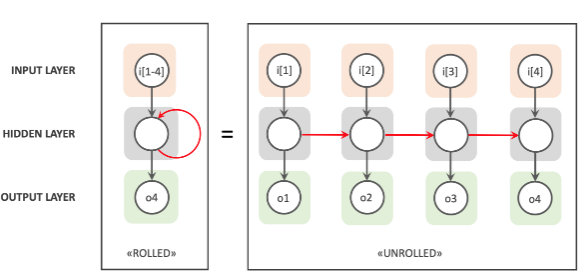

*** RNN의 장점
- 구조 단순
- 시계열 처리 가능
- 구현 쉬움



*** RNN의 단점
- 오래된 정보를 잘 기억하지 못함



*** RNN 문제
- 기울기 소실
- 오래된 정보 사라짐
- 즉, 문장이 길어질수록 → 앞의 정보 기억 불가


*** 그래서 등장한 것이 -> LSTM ( Long Short-Term Memory )
- 기억을 오래 유지
- 불필요한 정보는 삭제
- RNN은 기억을 그냥 넘겨주지만, LSTM은 기억을 남길지 말지를 스스로 결정

## LSTM ( Long Short-Term Memory )
- RNN에 ‘기억을 조절하는 장치’를 추가한 신경망
- LSTM = RNN + 기억 조절

- RNN  : 기억이 그냥 흘러감
- LSTM : 기억을 선택적으로 관리

*** LSTM 활용분야 : 주가 예측, 자연어 처리, 음성 인식 등

*** LSTM의 3가지 게이트
- Forget Gate (망각) : “이전 기억 중 뭐를 지울까?” (불필요한 과거 삭제)
- Input Gate (저장)  : “지금 들어온 것 중 뭐를 기억할까?” (중요한 현재 정보 저장)
- Output Gate (출력) : “기억 중 뭐를 써서 결과를 낼까?” (출력에 쓸 기억 선택)

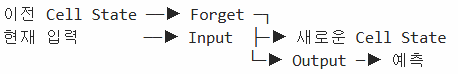
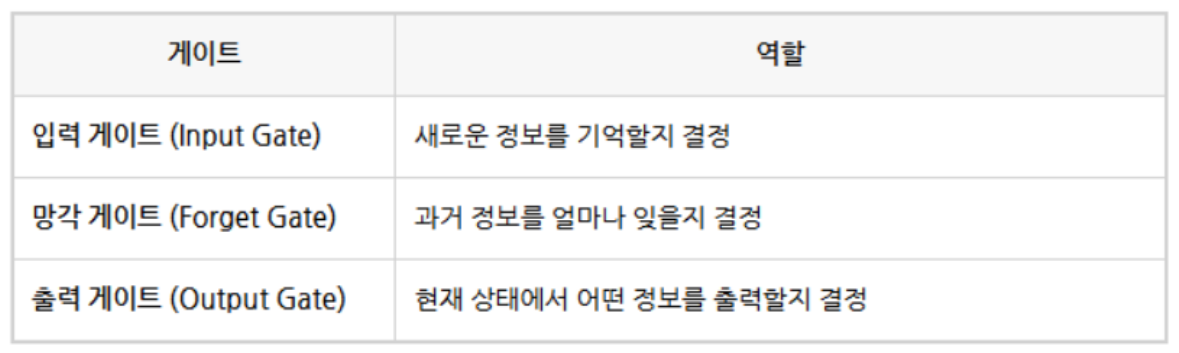

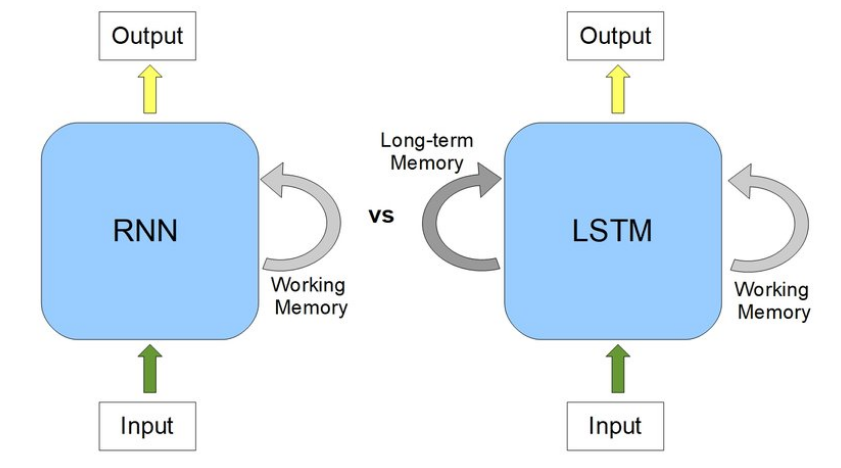

!pip install tensorflow-cpu keras

In [4]:
# tensorflow-cpu가 동작하는지 확인

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # 로그 수준 조절 (안내 메시지 숨김)
os.environ["CUDA_VISIBLE_DEVICES"] = "-1" # GPU 사용 안 함

import tensorflow as tf

# 실제 인식된 장치 목록만 깔끔하게 출력
devices = tf.config.list_physical_devices()
print(f"✅ 사용 가능한 기기 목록: {devices}")

# 간단한 연산 테스트
a = tf.constant([[1.0, 2.0]])
b = tf.constant([[3.0], [4.0]])
print(f"✅ CPU 연산 테스트 결과: {tf.matmul(a, b).numpy()}")

✅ 사용 가능한 기기 목록: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
✅ CPU 연산 테스트 결과: [[11.]]


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

2026-02-04 20:35:58.423220: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
## 연속된 숫자 3개를 입력으로 받아, 다음 숫자를 예측하는 LSTM 시계열 예측 모델 ( 과거 3개의 숫자로 다음 숫자 예측하기 )

# 샘플 데이터 준비 
X = np.array([[[1], [2], [3]], [[2], [3], [4]], [[3], [4], [5]], [[4],[5],[6]]])
y = np.array([4, 5, 6, 7])  

# LSTM 모델 정의
model = Sequential()   # 층을 위에서 아래로 순차적으로 쌓겠다
model.add(LSTM(50, activation='relu', input_shape=(3, 1))) # activation='tanh',
model.add(Dense(1))  
model.compile(optimizer='adam', loss='mse') 

# 모델 학습
model.fit(X, y, epochs=200, batch_size=1)

# 예측
predicted_value = model.predict(X)
print(predicted_value)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 30.0268
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 29.2715
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 28.5237
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 27.6842
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 26.8144
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 25.9221
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 24.8781
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 23.9194
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 22.8818
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 21.5937
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 20.2061
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 18.6424
Epoch 13/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 16.7615
Epoch 14/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 15.0953
Epoch 15/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 12.7514
Epoc